In [1]:
!pip install taichi
%matplotlib inline

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.7 MB/s eta 0:00:00


[Taichi] Starting on arch=x64


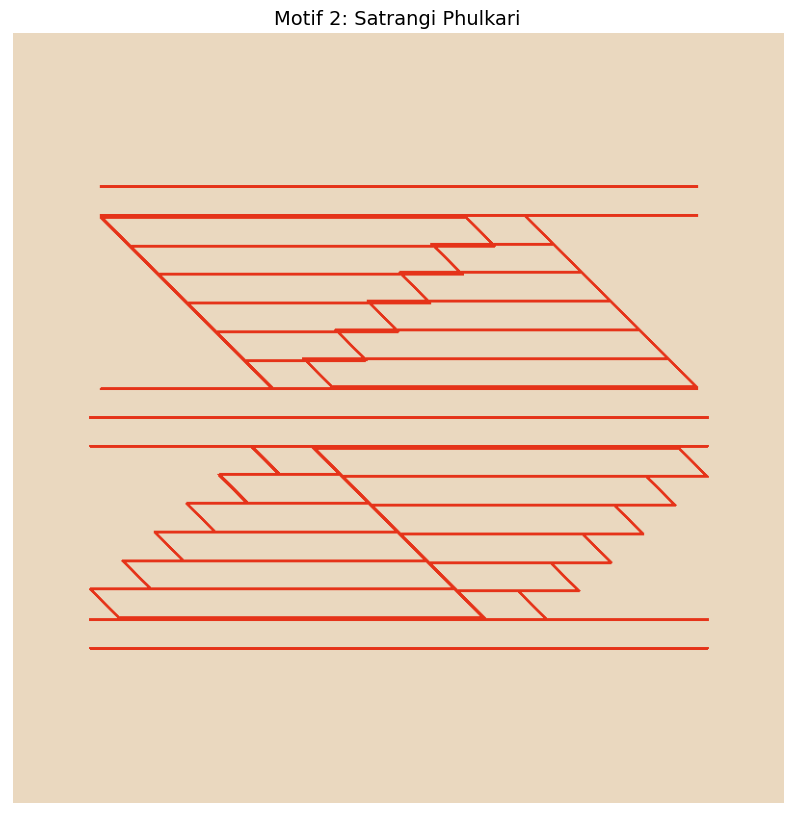

In [3]:
import math
import matplotlib.pyplot as plt
import taichi as ti
import numpy as np

# ============================================================
# TAICHI CONFIGURATION
# ============================================================
ti.init(arch=ti.cpu)
# ti.init(arch=ti.gpu) for local running

RES = 800
pixels = ti.Vector.field(3, dtype=ti.f32, shape=(RES, RES))

# 20,000 lines to handle both mini motifs in one
MAX_LINES = 20000
line_starts = ti.Vector.field(2, dtype=ti.f32, shape=MAX_LINES)
line_ends = ti.Vector.field(2, dtype=ti.f32, shape=MAX_LINES)

# ============================================================
# 1. L-SYSTEM EXPANDER
# ============================================================
def generate_l_system(axiom, rules, iterations):
    current = axiom
    for _ in range(iterations):
        temp = ""
        for ch in current:
            temp += rules.get(ch, ch)
        current = temp
    return current

# ============================================================
# 2. MOTIF 2 (Satrangi) -- Rules & Axioms
# ============================================================
rules = {
    "1": "AAA---------AA---AAA---------AA",
    "2": "AAAAAA---------AA---AAAAAA---------AA",
    "3": "AAAAAAAAA---------AA---AAAAAAAAA---------AA",
    "4": "AAAAAAAAAAAA---------AA---AAAAAAAAAAAA---------AA",
    "5": "AAAAAAAAAAAAAAA---------AA---AAAAAAAAAAAAAAA---------AA",
    "6": "AAAAAAAAAAAAAAAAAA---------AA---AAAAAAAAAAAAAAAAAA---------AA",
    "D": "aa---",
    # G turns 180° to face up-left, moves 2 units, then turns back to 0° (right)
    "G": "------------aa+++++++++",
}

axiomleft = "1G2G3G4G5G6"
axiomright = "6D5D4D3D2D1"

segments, stack = [], []

# ============================================================
# 3. TURTLE DRAW FUNCTION
# ============================================================
def turtle_draw(commands, stepA=20.0, turn=15.0,
                start_pos=(0.0, 0.0), start_angle=0.0):
    pos = list(start_pos)
    angle = start_angle
    for c in commands:
        if c == 'A':
            new_pos = [
                pos[0] + stepA * math.cos(math.radians(angle)),
                pos[1] + stepA * math.sin(math.radians(angle))
            ]
            segments.append((pos, new_pos))
            pos = new_pos
        elif c == 'a':
            pos = [
                pos[0] + stepA * math.cos(math.radians(angle)),
                pos[1] + stepA * math.sin(math.radians(angle))
            ]
        elif c == '+':
            angle -= turn
        elif c == '-':
            angle += turn
        elif c == '[':
            stack.append((pos[:], angle))
        elif c == ']':
            pos, angle = stack.pop()

# ============================================================
# 4. BORDER lines
# ============================================================
def add_border_lines(stepA=20.0, gap=15.0):
    """
    Calculates the bounds of the drawn motifs and adds lines
    above and below. The lines are the exact height of a parallelogram.
    """
    if not segments:
        return

    # 1. Find the boundaries of the existing motif
    min_x = min([min(p1[0], p2[0]) for p1, p2 in segments])
    max_x = max([max(p1[0], p2[0]) for p1, p2 in segments])
    min_y = min([min(p1[1], p2[1]) for p1, p2 in segments])
    max_y = max([max(p1[1], p2[1]) for p1, p2 in segments])

    # 2. Calculate the exact vertical height of a single parallelogram.
    rect_height = 2.0 * stepA * math.sin(math.radians(45.0))

    # --- TOP bar ---
    top_rect_y1 = max_y + gap
    top_rect_y2 = top_rect_y1 + rect_height

    segments.append(((min_x, top_rect_y1), (max_x, top_rect_y1)))  # Bottom edge
    segments.append(((min_x, top_rect_y2), (max_x, top_rect_y2)))  # Top edge

    # --- BOTTOM bar ---
    bottom_rect_y1 = min_y - gap
    bottom_rect_y2 = bottom_rect_y1 - rect_height

    segments.append(((min_x, bottom_rect_y1), (max_x, bottom_rect_y1)))  # Top edge
    segments.append(((min_x, bottom_rect_y2), (max_x, bottom_rect_y2)))  # Bottom edge

# 5. TAICHI gpu render engine

@ti.func
def distance_to_segment(p, a, b):
    pa = p - a
    ba = b - a
    baba = ba.dot(ba)
    h = 0.0
    if baba > 1e-5:
        h = ti.max(0.0, ti.min(pa.dot(ba) / baba, 1.0))
    return (pa - ba * h).norm()

@ti.kernel
def render_kernel(num_active_lines: ti.i32, thickness: ti.f32, scale: ti.f32, offset_x: ti.f32, offset_y: ti.f32):
    for i, j in pixels:
        pixels[i, j] = ti.Vector([0.92, 0.85, 0.75])
        p = ti.Vector([ti.cast(i, ti.f32), ti.cast(j, ti.f32)])
        for k in range(num_active_lines):
            a = line_starts[k] * scale + ti.Vector([offset_x, offset_y])
            b = line_ends[k] * scale + ti.Vector([offset_x, offset_y])

            # Bounding Box Optimization
            if p.x > ti.min(a.x, b.x) - 5 and p.x < ti.max(a.x, b.x) + 5 and \
               p.y > ti.min(a.y, b.y) - 5 and p.y < ti.max(a.y, b.y) + 5:
                if distance_to_segment(p, a, b) < thickness:
                    pixels[i, j] = ti.Vector([0.9, 0.2, 0.1])

def render_gpu_motif():
    num_active = min(len(segments), MAX_LINES)
    starts_np = np.zeros((MAX_LINES, 2), dtype=np.float32)
    ends_np = np.zeros((MAX_LINES, 2), dtype=np.float32)

    for idx in range(num_active):
        starts_np[idx] = segments[idx][0]
        ends_np[idx] = segments[idx][1]

    line_starts.from_numpy(starts_np)
    line_ends.from_numpy(ends_np)

    min_x = np.min(np.minimum(starts_np[:num_active, 0], ends_np[:num_active, 0]))
    max_x = np.max(np.maximum(starts_np[:num_active, 0], ends_np[:num_active, 0]))
    min_y = np.min(np.minimum(starts_np[:num_active, 1], ends_np[:num_active, 1]))
    max_y = np.max(np.maximum(starts_np[:num_active, 1], ends_np[:num_active, 1]))

    width, height = max_x - min_x, max_y - min_y
    center_x, center_y = (min_x + max_x) / 2.0, (min_y + max_y) / 2.0
    margin = 0.1 * RES
    scale = min((RES - 2 * margin) / width, (RES - 2 * margin) / height)
    offset_x = RES / 2.0 - center_x * scale
    offset_y = RES / 2.0 - center_y * scale

    render_kernel(num_active, 1.5, scale, offset_x, offset_y)

    img = pixels.to_numpy()
    plt.figure(figsize=(10, 10))
    plt.imshow(np.transpose(img, (1, 0, 2)), origin='lower')
    plt.axis('equal'); plt.axis('off')
    plt.title("Motif 2: Satrangi Phulkari", fontsize=14)
    plt.show()

# ============================================================
# MAIN EXECUTION
# ============================================================
if __name__ == "__main__":
    command1 = generate_l_system(axiomleft, rules, 1)
    command2 = generate_l_system(axiomright, rules, 1)

    # --------------------------------------------------------
    # 1. build bottom pattern (flipped)
    # --------------------------------------------------------
    segments.clear()
    turtle_draw(command2, stepA=20.0, turn=15.0, start_pos=(0.0, 0.0), start_angle=180.0)
    turtle_draw(command1, stepA=20.0, turn=15.0, start_pos=(30.0, -30.0), start_angle=0.0)
    add_border_lines(stepA=20.0, gap=0.0)

    # Save the bottom segments and find its bounding box and center
    bottom_motif_segments = list(segments)
    b_min_x = min([min(p1[0], p2[0]) for p1, p2 in bottom_motif_segments])
    b_max_x = max([max(p1[0], p2[0]) for p1, p2 in bottom_motif_segments])
    b_max_y = max([max(p1[1], p2[1]) for p1, p2 in bottom_motif_segments])
    b_center_x = (b_min_x + b_max_x) / 2.0

    # --------------------------------------------------------
    # Phase 2: Build the TOP Pattern (x_gap = -390.0)
    # --------------------------------------------------------
    segments.clear()
    turtle_draw(command2, stepA=20.0, turn=15.0, start_pos=(0.0, 0.0), start_angle=180.0)
    turtle_draw(command1, stepA=20.0, turn=15.0, start_pos=(-390.0, -30.0), start_angle=0.0)
    add_border_lines(stepA=20.0, gap=0.0)

    # Save the top segments and find its bounding box and center
    top_motif_segments = list(segments)
    t_min_x = min([min(p1[0], p2[0]) for p1, p2 in top_motif_segments])
    t_max_x = max([max(p1[0], p2[0]) for p1, p2 in top_motif_segments])
    t_min_y = min([min(p1[1], p2[1]) for p1, p2 in top_motif_segments])
    t_center_x = (t_min_x + t_max_x) / 2.0

    # --------------------------------------------------------
    # Phase 3: Combine both motifs to center
    # --------------------------------------------------------
    #1. Calculate exactly how far up the top pattern needs to move
    # so its bottom border rests perfectly on the bottom pattern's top border
    shift_up = b_max_y - t_min_y
    # Center the top pattern horizontally above the bottom pattern
    shift_x = b_center_x - t_center_x

    segments.clear()

    #add Bottom Pattern first
    segments.extend(bottom_motif_segments)

    #top pattern added whilst shifted dynamically up and centered
    for p1, p2 in top_motif_segments:
        shifted_p1 = (p1[0] + shift_x, p1[1] + shift_up)
        shifted_p2 = (p2[0] + shift_x, p2[1] + shift_up)
        segments.append((shifted_p1, shifted_p2))

    # render:
    # --------------------------------------------------------
    render_gpu_motif()